In [ ]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage, HumanMessage

load_dotenv()

model = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.3-70b-versatile",
    temperature=0.0
)


#### **Tools**

##### **DuckDuckGo Search Tool**

In [43]:
from langchain_community.tools import DuckDuckGoSearchRun

duck_search = DuckDuckGoSearchRun()
duck_search.invoke("latest news on high frequency treading")

'2 days ago - If a HFT firm is able to access and process information which predicts these changes before the tracker funds do so, they can buy up securities in advance of the trackers and sell them on to them at a profit. Company news in electronic text format is available from many sources including commercial providers like Bloomberg, public news websites, and Twitter feeds. Automated systems can identify company names, keywords and sometimes semantics to make news-based trades before human traders can process the news. A separate, "naïve" class of high-frequency trading strategies relies exclusively on ultra-low latency direct market access technology. 4 days ago - Ankit and Nishil Gupta started Graviton Research Capital LLP with a million dollars and a dream to put India on the global high-frequency trading map. April 1, 2026 - High-frequency trading (HFT) is no longer limited to institutions; it’s gradually becoming accessible to retail traders in India thanks to faster - Nagpur 

##### **Arxiv Research Paper**

In [ ]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

docs = retriever.invoke("What is the ImageBind model?")

###### **Another way To Implementation**

In [45]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arixv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

arixv_query.invoke("What is the ImageBind model?")

'Published: 2023-05-31\nTitle: ImageBind: One Embedding Space To Bind Them All\nAuthors: Rohit Girdhar, Alaaeldin El-Nouby, Zhuang Liu, Mannat Singh, Kalyan Vasudev Alwala, Armand Joulin, Ishan Misra\nSummary: We present ImageBind, an approach to learn a joint embedding across six different modalities - images, text, audio, depth, thermal, and IMU data. We show that all combinations of paired data are not necessary to train such a joint embedding, and only image-paired data is sufficient to bind the modalities together. ImageBind can leverage recent large scale vision-language models, and extends their zero-shot capabilities to new modalities just by using their natural pairing with images. It enables novel emergent applications \'out-of-the-box\' including cross-modal retrieval, composing modalities with arithmetic, cross-modal detection and generation. The emergent capabilities improve with the strength of the image encoder and we set a new state-of-the-art on emergent zero-shot reco

#### **Wikipedia SearchTool**

In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wikipedia_query.invoke("what is High frequency Trading?")

#### **Custom Tool**

In [ ]:
from langchain.tools import tool

@tool
def personalInfo(name : str):
    """ Use this tool to get personal information about alice, bob and dhanushkumar """
    info = {
        "alice" : "Alice is a software developer with 5 years of experience in AI",
        "bob" : "Bob is framer in North America and he grown the appline in his farm",
        "dhanushkumar" : "The dhanushkumar is Backend developer devops enginneer, AI and Ml developer and many more he is an polymorth with 3 years of experience"
    }

    return info.get(name, "No information avaliable for this person")

In [ ]:
personalInfo.invoke("dhanushkumar")

'The dhanushkumar is Backend developer devops enginneer, AI and Ml developer and many more he is an polymorth with 3 years of experience'

#### **Tool Binding**

In [ ]:
tools = [duck_search, arixv_query, wikipedia_query, personalInfo]
llm_with_tools = model.bind_tools(tools)

#### **LangGraph Creation**

In [47]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages : List

In [ ]:
from langchain_core.prompts import MessagesPlaceholder

def llm_node(state : graph_schema) -> graph_schema:
    messages = state['messages']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that can use tools to answer questions."),
        MessagesPlaceholder(variable_name="messages")
    ])

    chain = prompt | llm_with_tools

    # Pass the messages into the placeholder
    response = chain.invoke({"messages" : messages})
    state['messages'].append(response)

    return state


In [76]:
def tool_node(state : graph_schema) -> graph_schema:
    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tools_result = []

    # Get the last AI message that contains the tool_calls
    last_message = messages[-1]

    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call['name']]

        # Invoke the tool using the arguments from tool_call
        observation = tool.invoke(tool_call['args'])

        # IMPORTANT: Use tool_call['id'] instead of tool['id']
        tools_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call['id']))

    # Append the tool results to the state
    state['messages'] = messages + tools_result
    return state


#### **Create Conditional Edge Function**

In [77]:
def if_tool_call(state : graph_schema) -> str:
    lastMessage = state['messages'][-1]

    if lastMessage.tool_calls:
        return "tool node"
    else:
        return END

In [78]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool node", tool_node)

# edges
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool node" : "tool node", "end" : END})
graph.add_edge("tool node", "llm_node")
graph.add_edge("llm_node", END)

ReActGraph = graph.compile()

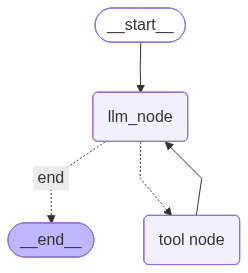

In [79]:
from IPython.display import Image, display

#  display the graph
Image(ReActGraph.get_graph().draw_mermaid_png())

#### **Graph Invocation**

In [ ]:
ReActGraph.invoke({
    "messages" : [HumanMessage(content="What is the latest news in ai?")]
})